In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/autosort-ai

agent.ipynb					       db.ipynb
analysis.ipynb					       intent_classifier.pkl
Bitext_Sample_Customer_Service_Testing_Dataset.csv     main.ipynb
Bitext_Sample_Customer_Service_Training_Dataset.csv    README.md
Bitext_Sample_Customer_Service_Validation_Dataset.csv  requirements.gdoc
classifier.ipynb


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/autosort-ai/Bitext_Sample_Customer_Service_Training_Dataset.csv")
val_df = pd.read_csv("/content/drive/MyDrive/autosort-ai/Bitext_Sample_Customer_Service_Validation_Dataset.csv")
test_df = pd.read_csv("/content/drive/MyDrive/autosort-ai/Bitext_Sample_Customer_Service_Testing_Dataset.csv")

df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

print(f"Total samples: {len(df)}")
df.head()

Total samples: 8175


,utterance,intent,category,tags
0,would it be possible to cancel the order I made?,cancel_order,ORDER,BIP
1,cancelling order,cancel_order,ORDER,BK
2,I need assistance canceling the last order I h...,cancel_order,ORDER,B
3,problem with canceling the order I made,cancel_order,ORDER,B
4,I don't know how to cancel the order I made,cancel_order,ORDER,B


<ipython-input-21-449a56fffb77>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=intent_counts.index, x=intent_counts.values, palette="viridis")


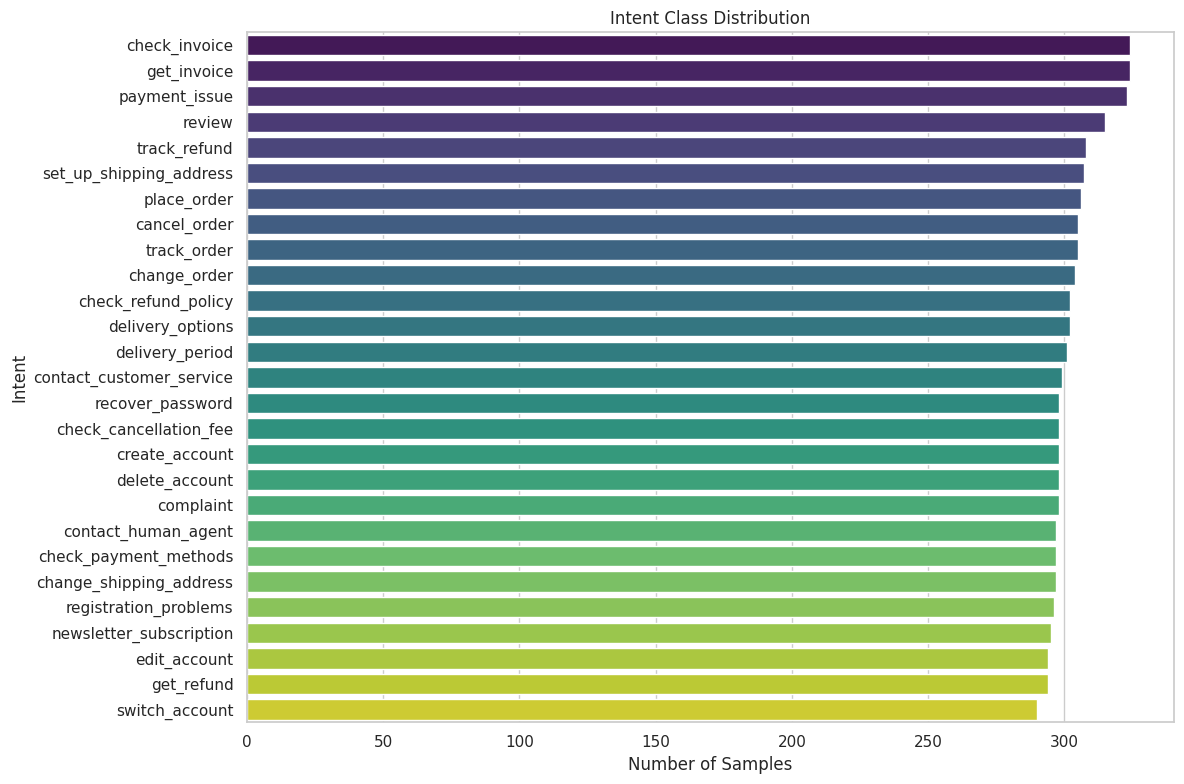

In [ ]:
intent_counts = df['intent'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(y=intent_counts.index, x=intent_counts.values, palette="viridis")
plt.title("Intent Class Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

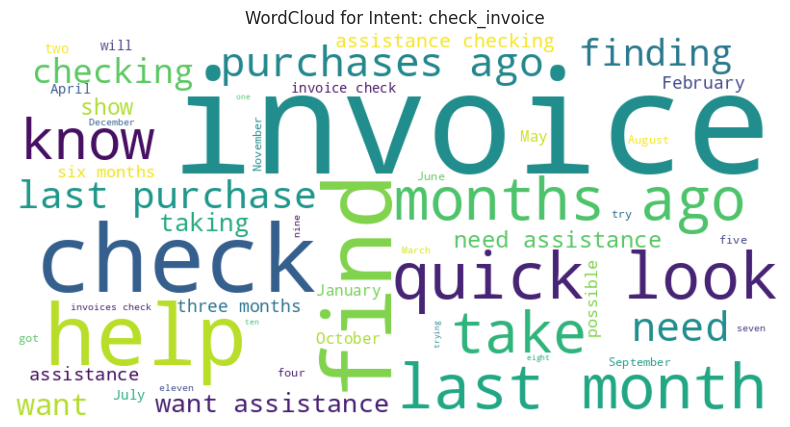

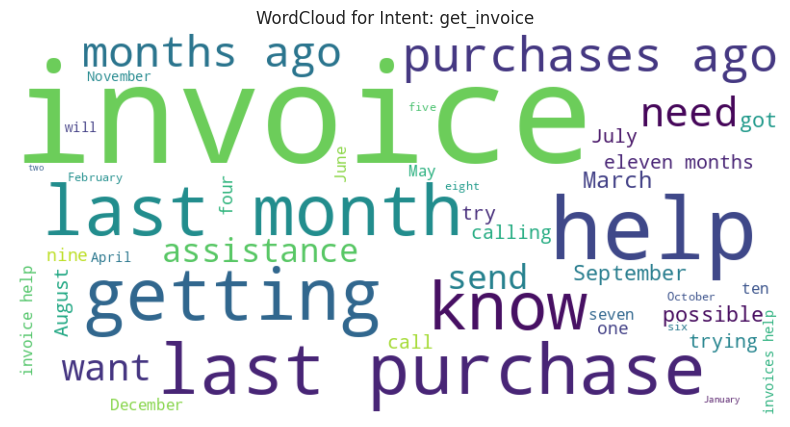

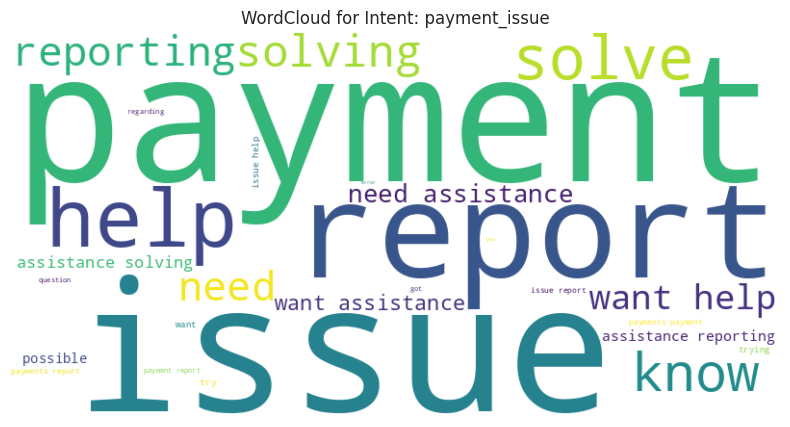

In [ ]:
# Create wordcloud for top 3 intents
top_intents = intent_counts.head(3).index.tolist()

for intent in top_intents:
    text = " ".join(df[df["intent"] == intent]["utterance"].values)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud for Intent: {intent}")
    plt.show()

In [ ]:
import re

# Get top 3 most frequent intents
intent_counts = df["intent"].value_counts()
top_intents = intent_counts.head(3).index.tolist()

# Extract and print word lists for each top intent
for intent in top_intents:
    # Join all utterances into one large string
    text = " ".join(df[df["intent"] == intent]["utterance"].values)

    # Basic text cleaning and tokenization
    words = re.findall(r'\b\w+\b', text.lower())  # lowercased and split into words
    unique_words = sorted(set(words))  # remove duplicates and sort

    # Display result
    print(f"\n🗂 Words for Intent: {intent} ({len(unique_words)} unique words):")
    print(unique_words)



🗂 Words for Intent: check_invoice (87 unique words):
['1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'ago', 'am', 'april', 'assistance', 'at', 'august', 'be', 'can', 'cannot', 'check', 'checking', 'could', 'december', 'do', 'don', 'eight', 'eleven', 'february', 'find', 'finding', 'five', 'four', 'from', 'got', 'have', 'help', 'how', 'i', 'invoice', 'invoices', 'is', 'it', 'january', 'july', 'june', 'know', 'last', 'like', 'look', 'march', 'may', 'me', 'month', 'months', 'my', 'need', 'nine', 'not', 'november', 'october', 'one', 'possible', 'purchase', 'purchases', 'quick', 'september', 'seven', 'show', 'six', 't', 'take', 'taking', 'ten', 'the', 'three', 'to', 'try', 'trying', 'two', 'want', 'what', 'where', 'will', 'would', 'you']

🗂 Words for Intent: get_invoice (78 unique words):
['1', '10', '11', '2', '3', '5', '6', '7', '8', '9', 'ago', 'am', 'april', 'assistance', 'august', 'be', 'call', 'calling', 'can', 'could', 'december', 'do', 'don', 'eight', 'eleven', 'febru

In [ ]:
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=3000)
X_train = vectorizer.fit_transform(train_df["utterance"])
X_test = vectorizer.transform(test_df["utterance"])
y_train = train_df["intent"]
y_test = test_df["intent"]

# Train simple logistic regression model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)

Classification Report:

                          precision    recall  f1-score   support

            cancel_order       1.00      0.96      0.98        25
            change_order       1.00      1.00      1.00        39
 change_shipping_address       1.00      1.00      1.00        41
  check_cancellation_fee       1.00      1.00      1.00        26
           check_invoice       1.00      1.00      1.00        31
   check_payment_methods       1.00      1.00      1.00        26
     check_refund_policy       1.00      1.00      1.00        37
               complaint       1.00      1.00      1.00        23
contact_customer_service       1.00      1.00      1.00        24
     contact_human_agent       1.00      1.00      1.00        42
          create_account       0.96      0.96      0.96        25
          delete_account       1.00      1.00      1.00        29
        delivery_options       1.00      1.00      1.00        32
         delivery_period       0.97      1.00      

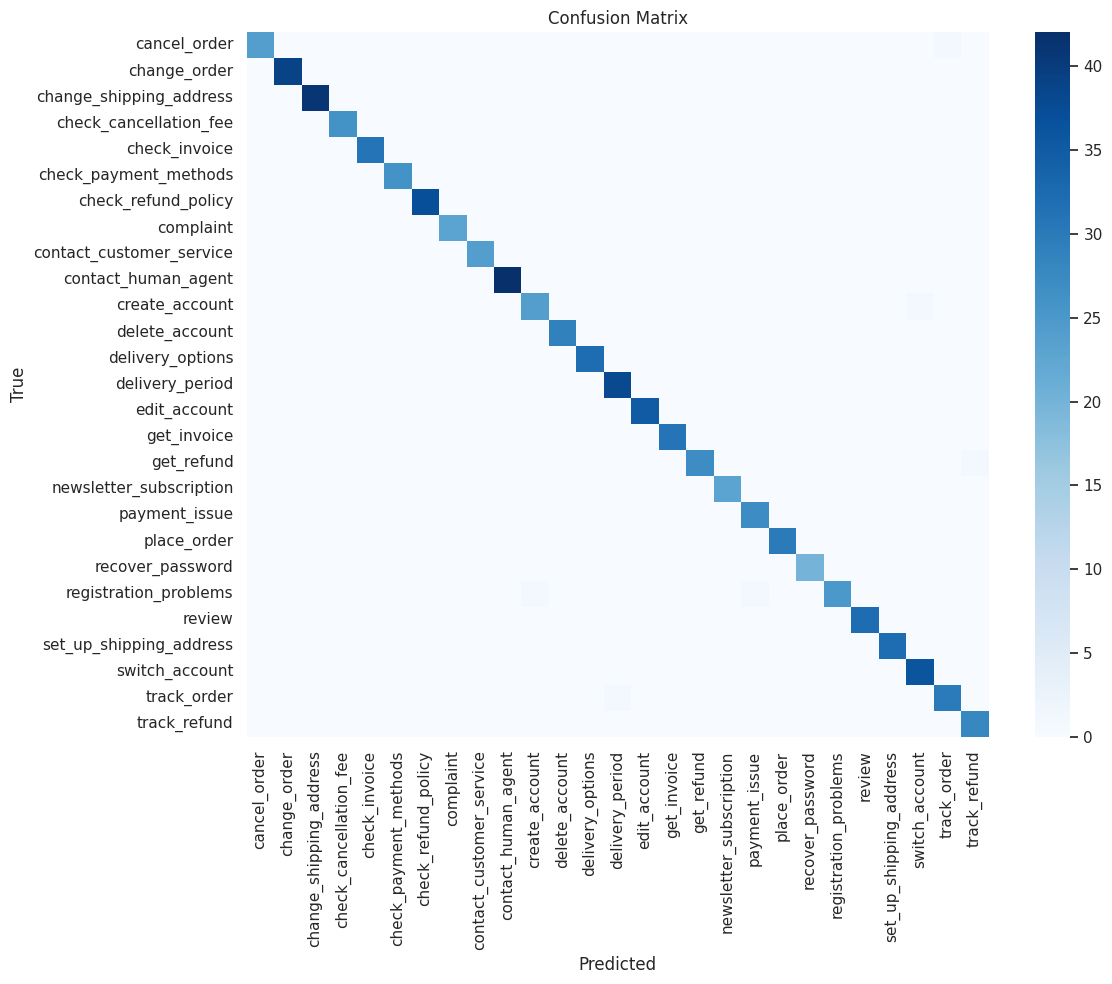

In [ ]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Summary
The dataset includes 27 different customer service intent classes.

Some classes are more represented than others, indicating slight class imbalance.

TF-IDF analysis shows distinct vocabularies across intents.

A baseline Logistic Regression model achieved high accuracy and precision/recall across most intents.

Confusion matrix shows good separation, with minor misclassifications between similar intents (e.g., Return Order vs. Cancel Order).

The model is promising as a baseline for intelligent agentic AI routing in customer service tasks.